In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base = Path().resolve().parent
csv_file = base / "diabetes.csv"

df = pd.read_csv(csv_file)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.shape

(768, 9)

In [6]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Missing Values already imputed as 0

In [7]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [15]:
df_1 = df.copy()
cols = df_1.columns.drop(["Pregnancies", "Outcome"])
df_1[cols] = df_1[cols].replace(0, np.nan)

df_1

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1


In [21]:
features_nan = [feature for feature in cols if df_1[feature].isnull().sum()>0] 
features_nan

['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

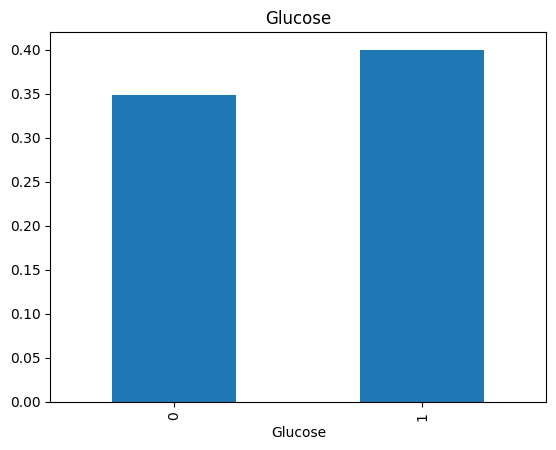

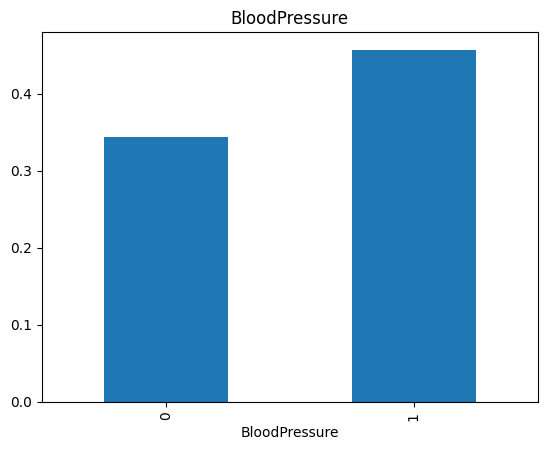

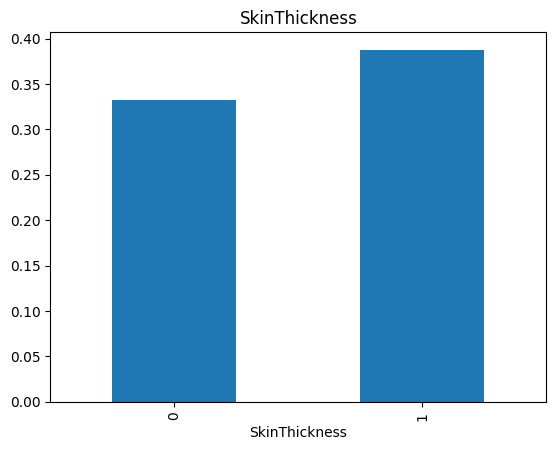

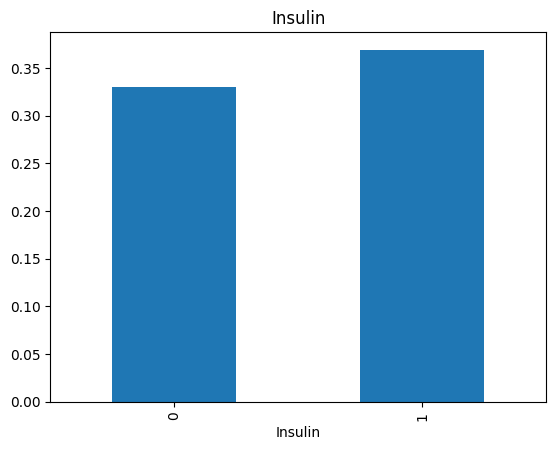

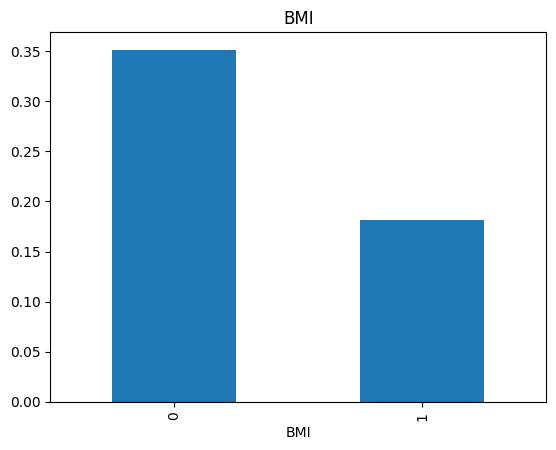

In [27]:
for feature in features_nan:
    data = df_1.copy()
    data[feature] = np.where(df_1[feature].isnull(), 1, 0)
    #Let's calculate the median Sale's price where the information is missing or provided
    data.groupby(feature)["Outcome"].mean().plot.bar()
    plt.title(feature)
    plt.show()
    

In [29]:
for feature in features_nan:
    data[feature+"_nan"] = np.where(data[feature].isnull(), 1, 0)
data.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_nan,BloodPressure_nan,SkinThickness_nan,Insulin_nan,BMI_nan
0,6,148.0,72.0,35.0,NaN,0,0.627,50,1,0,0,0,1,0
1,1,85.0,66.0,29.0,NaN,0,0.351,31,0,0,0,0,1,0
2,8,183.0,64.0,NaN,NaN,0,0.672,32,1,0,0,1,1,0
3,1,89.0,66.0,23.0,94.0,0,0.167,21,0,0,0,0,0,0
4,0,137.0,40.0,35.0,168.0,0,2.288,33,1,0,0,0,0,0


In [33]:
for feature in features_nan:
    median_0 = data[data["Outcome"] == 0][feature].median()
    median_1 = data[data["Outcome"] == 1][feature].median()

    data.loc[(data[feature].isnull()) & (data["Outcome"] == 0), feature] = median_0
    data.loc[(data[feature].isnull()) & (data["Outcome"] == 1), feature] = median_1
    



In [34]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
Glucose_nan                 0
BloodPressure_nan           0
SkinThickness_nan           0
Insulin_nan                 0
BMI_nan                     0
dtype: int64

## Numerical columns analysis
Check for outliers,skewness, rare categorical variables etc

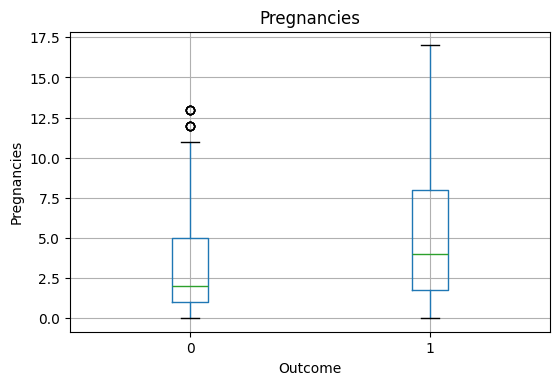

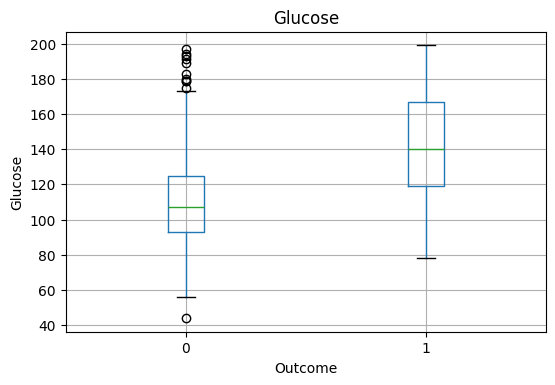

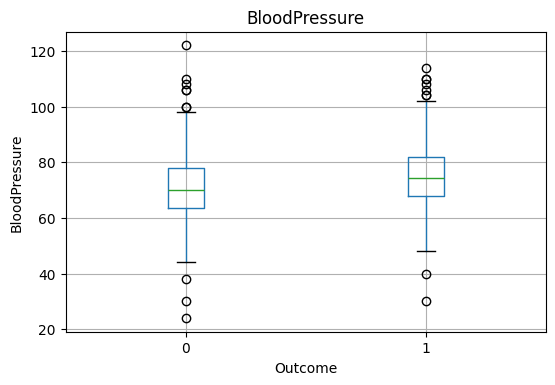

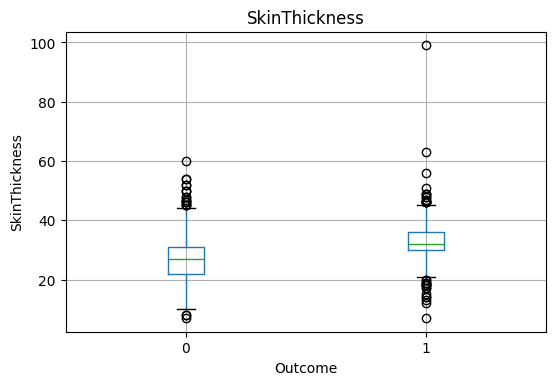

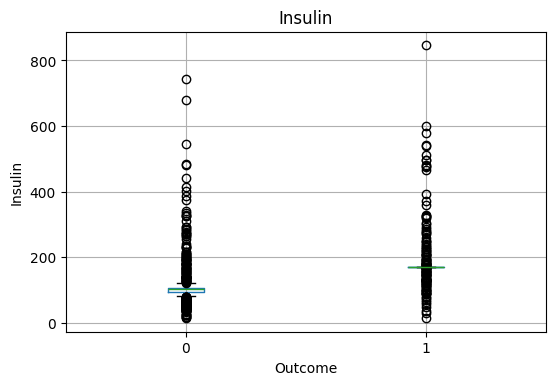

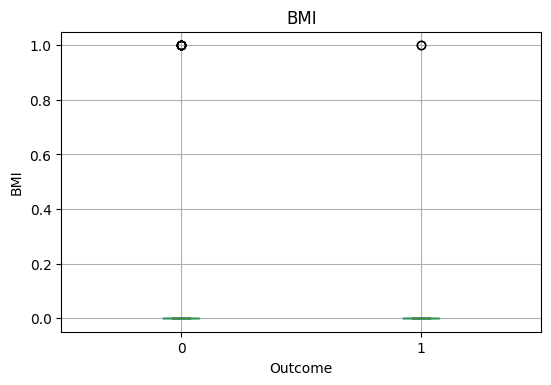

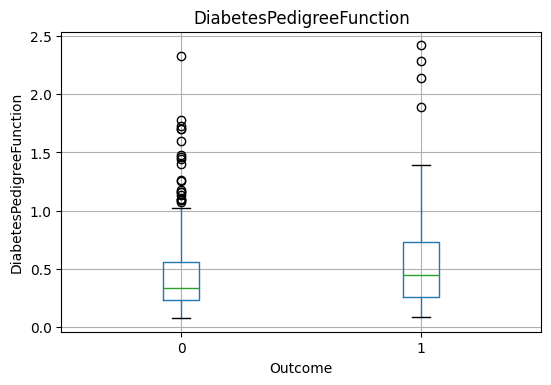

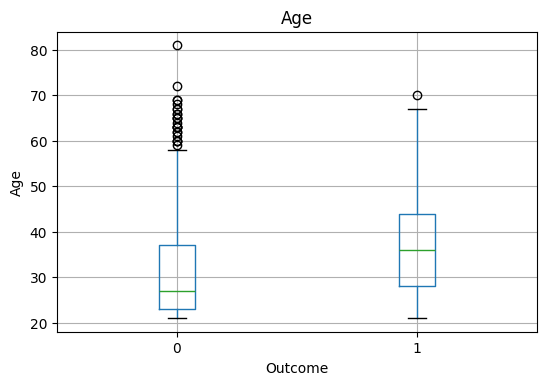

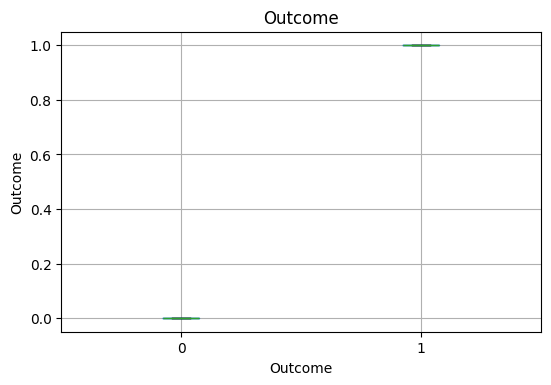

In [39]:
for feature in df_1.columns:
    data.boxplot(column=feature, by="Outcome", figsize=(6,4))
    plt.title(feature)
    plt.suptitle("")
    plt.xlabel("Outcome")
    plt.ylabel(feature)
    plt.show()
                    
                    

## Outliers detected in original dataset

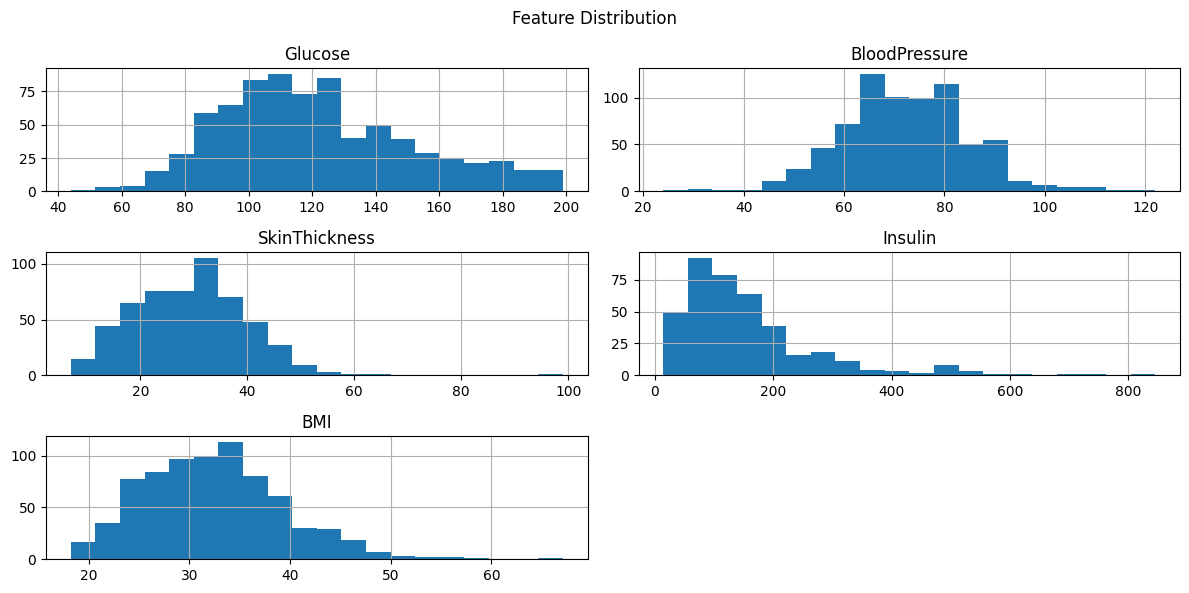

In [40]:
## visualize distributions
df_1[features_nan].hist(figsize=(12,6), bins=20)
plt.suptitle("Feature Distribution")
plt.tight_layout()
plt.show()


In [ ]:
for feature in df_1.columns:
    Q1 = 